In [4]:



import pandas as pd
from sqlalchemy import create_engine
import urllib.parse

server = r"LAPTOP-5Q4281GR"  
database = "Fintech"

params = urllib.parse.quote_plus(
    f"DRIVER=ODBC Driver 17 for SQL Server;"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
    f"TrustServerCertificate=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")




### Data import

In [5]:
pd.read_sql("SELECT TOP 1 * FROM application_train", engine)

c:\anaconda3\envs\venv\Lib\site-packages\pandas\io\sql.py:1649: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,None,None,0,202500.0,406597.5,24700.5,...,0,0,0,0,0,0,0,0,0,1


In [6]:
# 2) Read train feature-table query and execute
train_sql_path = r"c:\Users\Anamika Mishra\OneDrive\Desktop\FinTech\home_credit\sql\05_feature_table_one_row_per_application.sql"
with open(train_sql_path, "r", encoding="utf-8") as f:
    query_train = f.read()

df_train = pd.read_sql(query_train, engine)

print("Train shape:", df_train.shape)
print(df_train.head(2))

Train shape: (307511, 65)
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100008       0         Cash loans           M         None   
1      100009       0         Cash loans           F         None   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0            None             0           99000.0    490495.5      27517.5   
1            None             1          171000.0   1560726.0      41301.0   

   ...  cc_total_limit cc_total_drawings cc_total_payments  \
0  ...             0.0               0.0               0.0   
1  ...             0.0               0.0               0.0   

  cc_total_receivable cc_months_with_dpd  cc_max_dpd  cc_max_dpd_def  \
0                 0.0                  0           0               0   
1                 0.0                  0           0               0   

   cc_cnt_drawings_atm  cc_cnt_drawings  cc_cnt_instalments_paid  
0                    0                0                     

In [7]:
df_train.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,cc_total_limit,cc_total_drawings,cc_total_payments,cc_total_receivable,cc_months_with_dpd,cc_max_dpd,cc_max_dpd_def,cc_cnt_drawings_atm,cc_cnt_drawings,cc_cnt_instalments_paid
0,100008,0,Cash loans,M,None,None,0,99000.0,490495.5,27517.5,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0
1,100009,0,Cash loans,F,None,None,1,171000.0,1560726.0,41301.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0
2,100016,0,Cash loans,F,None,None,0,67500.0,80865.0,5881.5,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0
3,100018,0,Cash loans,F,None,None,0,189000.0,773680.5,32778.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0
4,100025,0,Cash loans,F,None,None,1,202500.0,1132573.5,37561.5,...,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0


In [8]:
# 3) Read test feature-table query and execute
train_sql_path = r"c:\Users\Anamika Mishra\OneDrive\Desktop\FinTech\home_credit\sql\05_feature_table_test.sql"
with open(train_sql_path, "r", encoding="utf-8") as f:
    query_train = f.read()

df_test = pd.read_sql(query_train, engine)

print("Test shape:", df_test.shape)
print(df_test.head(2))

Test shape: (48744, 64)
   SK_ID_CURR NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  \
0      100001         Cash loans           F         None            None   
1      100042         Cash loans           F         None            None   

   CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  \
0             0          135000.0    568800.0      20560.5         450000.0   
1             0          270000.0    959688.0      34600.5         810000.0   

   ... cc_total_limit cc_total_drawings cc_total_payments cc_total_receivable  \
0  ...            0.0              0.00              0.00                0.00   
1  ...      6615000.0         497606.49         626027.13          2797043.76   

   cc_months_with_dpd  cc_max_dpd  cc_max_dpd_def  cc_cnt_drawings_atm  \
0                   0           0               0                    0   
1                   2           1               0                   19   

   cc_cnt_drawings  cc_cnt_instalments_

## 2.) Understanding & Cleaning Data


In [9]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 65 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307511 non-null  int64  
 1   TARGET                       307511 non-null  int64  
 2   NAME_CONTRACT_TYPE           307511 non-null  str    
 3   CODE_GENDER                  307511 non-null  str    
 4   FLAG_OWN_CAR                 0 non-null       object 
 5   FLAG_OWN_REALTY              0 non-null       object 
 6   CNT_CHILDREN                 307511 non-null  int64  
 7   AMT_INCOME_TOTAL             307511 non-null  float64
 8   AMT_CREDIT                   307511 non-null  float64
 9   AMT_ANNUITY                  307499 non-null  float64
 10  AMT_GOODS_PRICE              307233 non-null  float64
 11  NAME_INCOME_TYPE             307511 non-null  str    
 12  NAME_EDUCATION_TYPE          307511 non-null  str    
 13  NAME_FAMIL

In [11]:
df_train.isnull().sum()

SK_ID_CURR                          0
TARGET                              0
NAME_CONTRACT_TYPE                  0
CODE_GENDER                         0
FLAG_OWN_CAR                   307511
FLAG_OWN_REALTY                307511
CNT_CHILDREN                        0
AMT_INCOME_TOTAL                    0
AMT_CREDIT                          0
AMT_ANNUITY                        12
AMT_GOODS_PRICE                   278
NAME_INCOME_TYPE                    0
NAME_EDUCATION_TYPE                 0
NAME_FAMILY_STATUS                  0
NAME_HOUSING_TYPE                   0
DAYS_BIRTH                          0
DAYS_EMPLOYED                       0
DAYS_REGISTRATION                   0
DAYS_ID_PUBLISH                     0
OWN_CAR_AGE                    202929
EXT_SOURCE_1                   173378
EXT_SOURCE_2                      660
EXT_SOURCE_3                    60965
OCCUPATION_TYPE                 96391
CNT_FAM_MEMBERS                     2
REGION_RATING_CLIENT                0
REGION_RATIN

In [ ]:
# STEP 4) Data cleaning 
import numpy as np
import pandas as pd

ID_COL = "SK_ID_CURR"
TARGET_COL = "TARGET"  

df_train = df_train.copy()
df_test = df_test.copy()

# ----------------------------
# A) Basic cleanup
# ----------------------------
# 1) Replace empty strings with NaN
for df in (df_train, df_test):
    obj_cols = df.select_dtypes(include=["object"]).columns
    for c in obj_cols:
      df[c] = df[c].replace(["None", "none", "NULL", "", " "], np.nan)

# 2) Strip whitespace for string columns
for df in (df_train, df_test):
    obj_cols = df.select_dtypes(include=["object"]).columns
    for c in obj_cols:
        df[c] = df[c].astype("string")
        df[c] = df[c].str.strip()



C:\Users\Anamika Mishra\AppData\Local\Temp\ipykernel_50872\1641219404.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include=["object"]).columns
C:\Users\Anamika Mishra\AppData\Local\Temp\ipykernel_50872\1641219404.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata

In [13]:
df_train.isnull().sum()

SK_ID_CURR                          0
TARGET                              0
NAME_CONTRACT_TYPE                  0
CODE_GENDER                         0
FLAG_OWN_CAR                   307511
FLAG_OWN_REALTY                307511
CNT_CHILDREN                        0
AMT_INCOME_TOTAL                    0
AMT_CREDIT                          0
AMT_ANNUITY                        12
AMT_GOODS_PRICE                   278
NAME_INCOME_TYPE                    0
NAME_EDUCATION_TYPE                 0
NAME_FAMILY_STATUS                  0
NAME_HOUSING_TYPE                   0
DAYS_BIRTH                          0
DAYS_EMPLOYED                       0
DAYS_REGISTRATION                   0
DAYS_ID_PUBLISH                     0
OWN_CAR_AGE                    202929
EXT_SOURCE_1                   173378
EXT_SOURCE_2                      660
EXT_SOURCE_3                    60965
OCCUPATION_TYPE                 96391
CNT_FAM_MEMBERS                     2
REGION_RATING_CLIENT                0
REGION_RATIN

In [ ]:
# ----------------------------
# B) Duplicates / key integrity
# ----------------------------
# Duplicates by SK_ID_CURR should not exist
dup_train = df_train[df_train[ID_COL].duplicated(keep=False)]
if len(dup_train) > 0:
    print("Duplicate SK_ID_CURR found in train:", dup_train.shape[0])
    # keeping first occurrence
    df_train = df_train.drop_duplicates(subset=[ID_COL], keep="first")

dup_test = df_test[df_test[ID_COL].duplicated(keep=False)]
if len(dup_test) > 0:
    print("Duplicate SK_ID_CURR found in test:", dup_test.shape[0])
    df_test = df_test.drop_duplicates(subset=[ID_COL], keep="first")



In [15]:
# 3) TARGET sanity (train only)
if TARGET_COL in df_train.columns:
    df_train = df_train[df_train[TARGET_COL].notna()].copy()
    # convert to integer 0/1 if needed
    df_train[TARGET_COL] = pd.to_numeric(df_train[TARGET_COL], errors="coerce").astype("Int64")
    df_train = df_train[df_train[TARGET_COL].notna()].copy()
    df_train[TARGET_COL] = df_train[TARGET_COL].astype(int)



In [16]:
# ----------------------------
# C) Coerce “object” columns to numeric
# ----------------------------
def coerce_object_to_numeric_if_good(df, good_frac=0.95, exclude_cols=None):
    exclude_cols = set(exclude_cols or [])
    obj_cols = [c for c in df.columns if df[c].dtype == "object" and c not in exclude_cols]
    numeric_converted = []
    for c in obj_cols:
        s = df[c]
        #numeric conversion
        converted = pd.to_numeric(s, errors="coerce")
        # If most values convert, keep as numeric
        conv_frac = converted.notna().mean()
        if conv_frac >= good_frac:
            df[c] = converted
            numeric_converted.append(c)
    return numeric_converted

exclude = {ID_COL, TARGET_COL}
coerced_train = coerce_object_to_numeric_if_good(df_train, good_frac=0.95, exclude_cols=exclude)
coerced_test  = coerce_object_to_numeric_if_good(df_test,  good_frac=0.95, exclude_cols=exclude)

print("Coerced to numeric (train):", len(coerced_train))
print("Coerced to numeric (test):", len(coerced_test))


Coerced to numeric (train): 0
Coerced to numeric (test): 0


In [17]:
# ----------------------------
# D) Identify numeric/categorical columns
# ----------------------------
feature_cols = [c for c in df_train.columns if c != TARGET_COL]
X_cols = feature_cols  # for train

numeric_cols = [c for c in X_cols if pd.api.types.is_numeric_dtype(df_train[c])]
categorical_cols = [c for c in X_cols if c not in numeric_cols]

print("Numeric cols:", len(numeric_cols))
print("Categorical cols:", len(categorical_cols))


Numeric cols: 55
Categorical cols: 9


In [18]:
# ----------------------------
# E) Prepare X and y
# ----------------------------
X_train = df_train.drop(columns=[TARGET_COL])
y_train = df_train[TARGET_COL].values

X_test = df_test.copy()


In [19]:
# quick missingness report
missing_train = (X_train.isna().mean().sort_values(ascending=False) * 100).round(2)
print("\nTop 15 missing columns in X_train (%):")
print(missing_train.head(15))



Top 15 missing columns in X_train (%):
FLAG_OWN_CAR          100.00
FLAG_OWN_REALTY       100.00
OWN_CAR_AGE            65.99
EXT_SOURCE_1           56.38
OCCUPATION_TYPE        31.35
EXT_SOURCE_3           19.83
EXT_SOURCE_2            0.21
AMT_GOODS_PRICE         0.09
AMT_ANNUITY             0.00
CNT_FAM_MEMBERS         0.00
AMT_CREDIT              0.00
AMT_INCOME_TOTAL        0.00
CODE_GENDER             0.00
CNT_CHILDREN            0.00
NAME_CONTRACT_TYPE      0.00
dtype: float64


### Handling missing values

In [20]:
import numpy as np
import pandas as pd

from sqlalchemy import true
ID_COL = "SK_ID_CURR"
TARGET_COL = "TARGET"

# 0) Make copies
df_train = df_train.copy()
df_test = df_test.copy()

# 1) Split y and X
y = df_train[TARGET_COL].astype(int)
X_train = df_train.drop(columns=[TARGET_COL])
X_test = df_test.copy()

# Keep IDs separately (useful later for submission)
train_ids = X_train[ID_COL]
test_ids = X_test[ID_COL]

# Drop ID from features
X_train = X_train.drop(columns=[ID_COL])
X_test = X_test.drop(columns=[ID_COL])


# 2) Find columns with >80% missing data
missing_rate = X_train.isna().mean()
drop_cols = missing_rate[missing_rate > 0.80].index.tolist()

# 3) DROP THEM PERMANENTLY (This wipes them completely out of X_train)
X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

# Recompute numeric/categorical lists AFTER the drop so the dropped cols are forgotten
num_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
cat_cols = [c for c in X_train.columns if c not in num_cols]

# 4) Create missing indicators ONLY for the columns that survived the drop!
cols_with_missing = [c for c in X_train.columns if X_train[c].isna().any()]

print(f"Creating indicators for these {len(cols_with_missing)} columns:", cols_with_missing)

for c in cols_with_missing:
    X_train[f"{c}_is_missing"] = X_train[c].isna().astype("int8")
    X_test[f"{c}_is_missing"] = X_test[c].isna().astype("int8")

# 5) Finally, Impute the missing values
num_fill = X_train[num_cols].median(numeric_only=True)
if len(cat_cols) > 0:
    cat_fill = X_train[cat_cols].mode(dropna=True).iloc[0]
else:
    cat_fill = pd.Series(dtype="object")

X_train[num_cols] = X_train[num_cols].fillna(num_fill)
X_test[num_cols] = X_test[num_cols].fillna(num_fill)

if len(cat_cols) > 0:
    X_train[cat_cols] = X_train[cat_cols].fillna(cat_fill)
    X_test[cat_cols] = X_test[cat_cols].fillna(cat_fill)

print("Remaining nulls in X_train:", int(X_train.isna().sum().sum()))


Creating indicators for these 8 columns: ['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'OWN_CAR_AGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS']
Remaining nulls in X_train: 0


## Feature Engineering

In [ ]:
import numpy as np
import pandas as pd

Xtr = X_train.copy()
Xte = X_test.copy()

EPS = 1e-6


# A) Ratio features
ratio_pairs = [
    ("credit_income_ratio", "AMT_CREDIT", "AMT_INCOME_TOTAL"),
    ("annuity_income_ratio", "AMT_ANNUITY", "AMT_INCOME_TOTAL"),
    ("credit_annuity_ratio", "AMT_CREDIT", "AMT_ANNUITY"),
    ("bureau_debt_income_ratio", "bureau_total_debt", "AMT_INCOME_TOTAL"),
    ("bureau_overdue_income_ratio", "bureau_total_overdue", "AMT_INCOME_TOTAL"),
    ("cc_utilization_ratio", "cc_total_balance", "cc_total_limit"),
    ("cc_payment_balance_ratio", "cc_total_payments", "cc_total_balance"),
    ("install_paid_scheduled_ratio", "total_paid", "total_scheduled"),
    ("late_payment_rate", "late_payment_count", "installment_rows"),
    ("pos_dpd_month_rate", "pos_months_with_dpd", "pos_monthly_rows"),
    ("cc_dpd_month_rate", "cc_months_with_dpd", "cc_monthly_rows"),
]

for new_col, num_col, den_col in ratio_pairs:
    if num_col in Xtr.columns and den_col in Xtr.columns:
        Xtr[new_col] = Xtr[num_col] / (Xtr[den_col] + EPS)
        Xte[new_col] = Xte[num_col] / (Xte[den_col] + EPS)



In [ ]:

# B) Difference features

if {"total_scheduled", "total_paid"}.issubset(Xtr.columns):
    Xtr["install_payment_gap"] = Xtr["total_scheduled"] - Xtr["total_paid"]
    Xte["install_payment_gap"] = Xte["total_scheduled"] - Xte["total_paid"]

if {"prev_total_amt_credit", "AMT_CREDIT"}.issubset(Xtr.columns):
    Xtr["prev_vs_current_credit_gap"] = Xtr["prev_total_amt_credit"] - Xtr["AMT_CREDIT"]
    Xte["prev_vs_current_credit_gap"] = Xte["prev_total_amt_credit"] - Xte["AMT_CREDIT"]


In [ ]:
# C) Age & employed years features
if "DAYS_BIRTH" in Xtr.columns:
    Xtr["AGE_YEARS"] = (-Xtr["DAYS_BIRTH"]) / 365.25
    Xte["AGE_YEARS"] = (-Xte["DAYS_BIRTH"]) / 365.25

if "DAYS_EMPLOYED" in Xtr.columns:
    # Flag the anomaly explicitly BEFORE cleaning it.
    Xtr["IS_PENSIONER"] = (Xtr["DAYS_EMPLOYED"] == 365243).astype(int)
    Xte["IS_PENSIONER"] = (Xte["DAYS_EMPLOYED"] == 365243).astype(int)

    
    Xtr["DAYS_EMPLOYED"] = Xtr["DAYS_EMPLOYED"].replace(365243, np.nan)
    Xte["DAYS_EMPLOYED"] = Xte["DAYS_EMPLOYED"].replace(365243, np.nan)

    Xtr["EMPLOYED_YEARS"] = np.where(
        Xtr["DAYS_EMPLOYED"].notna(),
        (-Xtr["DAYS_EMPLOYED"]) / 365.25,
        np.nan
    )
    Xte["EMPLOYED_YEARS"] = np.where(
        Xte["DAYS_EMPLOYED"].notna(),
        (-Xte["DAYS_EMPLOYED"]) / 365.25,
        np.nan
    )

# Fill NaNs introduced above with train median
for c in ["DAYS_EMPLOYED", "EMPLOYED_YEARS","AGE_YEARS"]:
    if c in Xtr.columns:
        med = Xtr[c].median()
        Xtr[c] = Xtr[c].fillna(med)
        Xte[c] = Xte[c].fillna(med)


In [ ]:
# Mean of the external scores
Xtr["EXT_SOURCE_MEAN"] = Xtr[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean(axis=1)
Xte["EXT_SOURCE_MEAN"] = Xte[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean(axis=1)

# Multiplication of the external scores
Xtr["EXT_SOURCE_PROD"] = Xtr["EXT_SOURCE_1"] * Xtr["EXT_SOURCE_2"] * Xtr["EXT_SOURCE_3"]
Xte["EXT_SOURCE_PROD"] = Xte["EXT_SOURCE_1"] * Xte["EXT_SOURCE_2"] * Xte["EXT_SOURCE_3"]


In [25]:
# How much of their income is left after paying this new loan's annuity?
Xtr["DISPOSABLE_INCOME"] = Xtr["AMT_INCOME_TOTAL"] - Xtr["AMT_ANNUITY"]
Xte["DISPOSABLE_INCOME"] = Xte["AMT_INCOME_TOTAL"] - Xte["AMT_ANNUITY"]

# How much of their loan goes to goods vs just getting cash?
# (If this ratio is very low, they are taking out a loan to pay off other debts, NOT to buy a car/house)
Xtr["GOODS_PRICE_TO_CREDIT_RATIO"] = Xtr["AMT_GOODS_PRICE"] / (Xtr["AMT_CREDIT"] + 1e-6)
Xte["GOODS_PRICE_TO_CREDIT_RATIO"] = Xte["AMT_GOODS_PRICE"] / (Xte["AMT_CREDIT"] + 1e-6)


In [ ]:

# E) Categorical cleanup

cat_cols = Xtr.select_dtypes(exclude=[np.number]).columns.tolist()

# Group rare categories into "Other" (reduces OHE explosion)
for c in cat_cols:
    freq = Xtr[c].value_counts(normalize=True, dropna=False)
    rare = freq[freq < 0.01].index   # threshold 1%
    Xtr[c] = Xtr[c].replace(rare, "Other")
    Xte[c] = Xte[c].replace(rare, "Other")

print("Feature engineering complete.")
print("Xtr shape:", Xtr.shape, "| Xte shape:", Xte.shape)

Feature engineering complete.
Xtr shape: (307511, 89) | Xte shape: (48744, 89)


In [27]:
print("Xtr rows:", Xtr.shape[0])
print("len(y):", len(y))
print("y unique:", np.unique(y))

Xtr rows: 307511
len(y): 307511
y unique: [0 1]


### EDA

In [ ]:

# EDA (Exploratory Data Analysis)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# EDA dataframe
eda_df = Xtr.copy()
eda_df["SK_ID_CURR"] = train_ids.values
eda_df["TARGET"] = y.values if hasattr(y, "values") else y

# putting ID first
eda_df = eda_df[["SK_ID_CURR", "TARGET"] + [c for c in eda_df.columns if c not in ("SK_ID_CURR","TARGET")]]

TARGET = "TARGET"
ID_COL = "SK_ID_CURR" if "SK_ID_CURR" in eda_df.columns else None

print("Shape:", eda_df.shape)
print("\nDtypes:")
print(eda_df.dtypes.value_counts())


Shape: (307511, 91)

Dtypes:
float64    45
int64      31
int8        8
string      7
Name: count, dtype: int64



TARGET counts:
 TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET default rate (mean): 0.0807


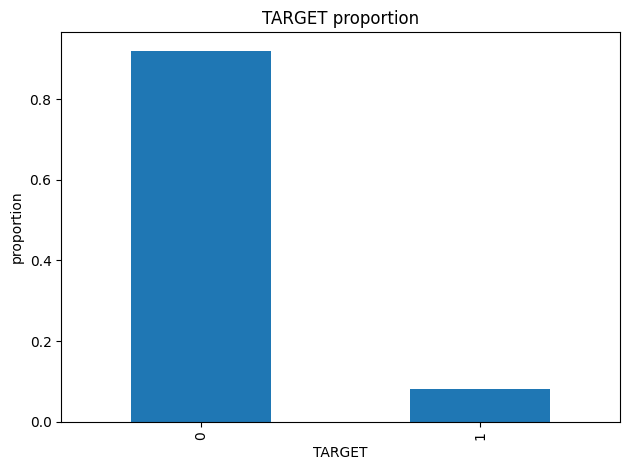

In [ ]:
# 1) Target balance

vc = eda_df[TARGET].value_counts().sort_index()
print("\nTARGET counts:\n", vc)
print("\nTARGET default rate (mean):", eda_df[TARGET].mean().round(4))

plt.figure()
eda_df[TARGET].value_counts(normalize=True).sort_index().plot(kind="bar")
plt.title("TARGET proportion")
plt.xlabel("TARGET")
plt.ylabel("proportion")
plt.tight_layout()
plt.show()



In [ ]:
# 2) Missing values after imputation

miss = (eda_df.isna().mean().sort_values(ascending=False) * 100).round(2)
print("\nTop 20 columns still missing (%):")
print(miss.head(20))



Top 20 columns still missing (%):
SK_ID_CURR             0.0
TARGET                 0.0
NAME_CONTRACT_TYPE     0.0
CODE_GENDER            0.0
CNT_CHILDREN           0.0
AMT_INCOME_TOTAL       0.0
AMT_CREDIT             0.0
AMT_ANNUITY            0.0
AMT_GOODS_PRICE        0.0
NAME_INCOME_TYPE       0.0
NAME_EDUCATION_TYPE    0.0
NAME_FAMILY_STATUS     0.0
NAME_HOUSING_TYPE      0.0
DAYS_BIRTH             0.0
DAYS_EMPLOYED          0.0
DAYS_REGISTRATION      0.0
DAYS_ID_PUBLISH        0.0
OWN_CAR_AGE            0.0
EXT_SOURCE_1           0.0
EXT_SOURCE_2           0.0
dtype: float64


In [ ]:
# 3) Numeric overview

num_cols = eda_df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in num_cols:
    num_cols.remove(TARGET)
if ID_COL and ID_COL in num_cols:
    num_cols.remove(ID_COL)

print("\nNumeric columns:", len(num_cols))
display(eda_df[num_cols].describe().T.head(20))  



Numeric columns: 82


,count,mean,std,min,25%,50%,75%,max
CNT_CHILDREN,307511.0,0.417052,7.221214e-01,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,2.371231e+05,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,4.024908e+05,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307511.0,27108.487841,1.449346e+04,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307511.0,538316.294367,3.692890e+05,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
DAYS_BIRTH,307511.0,-16036.995067,4.363989e+03,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,-2251.606131,2.136193e+03,-1.791200e+04,-2760.000000,-1648.000000,-933.000000,0.000000e+00
DAYS_REGISTRATION,307511.0,-4986.120328,3.522886e+03,-2.467200e+04,-7479.500000,-4504.000000,-2010.000000,0.000000e+00
DAYS_ID_PUBLISH,307511.0,-2994.202373,1.509450e+03,-7.197000e+03,-4299.000000,-3254.000000,-1720.000000,0.000000e+00
OWN_CAR_AGE,307511.0,10.041052,7.115228e+00,0.000000e+00,9.000000,9.000000,9.000000,9.100000e+01


In [ ]:
# 4) Quick “signal” table: numeric mean by TARGET

signal_num = (
    eda_df.groupby(TARGET)[num_cols].mean().T
    .assign(diff=lambda d: d[1] - d[0])
    .sort_values("diff", key=np.abs, ascending=False)
)

print("\nTop 15 numeric features by |mean(TARGET=1) - mean(TARGET=0)| :")
print(signal_num.head(15))




Top 15 numeric features by |mean(TARGET=1) - mean(TARGET=0)| :
TARGET                                   0             1          diff
cc_payment_balance_ratio      6.843454e+08  6.618828e+08 -2.246260e+07
cc_utilization_ratio          2.234533e+07  2.670544e+06 -1.967478e+07
install_paid_scheduled_ratio  8.990986e+06  9.306043e-01 -8.990985e+06
cc_total_limit                1.615468e+06  1.492792e+06 -1.226763e+05
cc_total_balance              6.107997e+05  7.259647e+05  1.151650e+05
cc_total_receivable           6.087072e+05  7.223982e+05  1.136910e+05
prev_vs_current_credit_gap    2.953748e+05  3.980003e+05  1.026255e+05
total_paid                    6.490890e+05  5.807172e+05 -6.837182e+04
prev_total_amt_credit         8.980231e+05  9.557788e+05  5.775570e+04
AMT_GOODS_PRICE               5.426525e+05  4.889394e+05 -5.371304e+04
total_scheduled               6.418601e+05  5.905543e+05 -5.130581e+04
AMT_CREDIT                    6.026483e+05  5.577785e+05 -4.486975e+04
cc_total_draw

In [ ]:
# 5) Key categoricals

cat_cols = eda_df.select_dtypes(exclude=[np.number]).columns.tolist()
if TARGET in cat_cols:
    cat_cols.remove(TARGET)
if ID_COL and ID_COL in cat_cols:
    cat_cols.remove(ID_COL)

# keep low-cardinality first 
cat_cols_sorted = sorted(cat_cols, key=lambda c: eda_df[c].nunique(dropna=False))
key_cats = [c for c in cat_cols_sorted if eda_df[c].nunique(dropna=False) <= 30][:12]

for c in key_cats:
    ct = pd.crosstab(eda_df[c], eda_df[TARGET], normalize="index")
    rate1 = ct.get(1, pd.Series(index=ct.index, data=np.nan))
    print(f"\n--- {c} (default rate by category) ---")
    print(rate1.sort_values(ascending=False).head(10))




--- NAME_CONTRACT_TYPE (default rate by category) ---
NAME_CONTRACT_TYPE
Cash loans         0.083459
Revolving loans    0.054783
Name: 1, dtype: float64

--- CODE_GENDER (default rate by category) ---
CODE_GENDER
M        0.101419
F        0.069993
Other    0.000000
Name: 1, dtype: float64

--- NAME_INCOME_TYPE (default rate by category) ---
NAME_INCOME_TYPE
Other                   0.181818
Working                 0.095885
Commercial associate    0.074843
State servant           0.057550
Pensioner               0.053864
Name: 1, dtype: float64

--- NAME_EDUCATION_TYPE (default rate by category) ---
NAME_EDUCATION_TYPE
Lower secondary                  0.109277
Secondary / secondary special    0.089399
Incomplete higher                0.084850
Higher education                 0.053551
Other                            0.018293
Name: 1, dtype: float64

--- NAME_HOUSING_TYPE (default rate by category) ---
NAME_HOUSING_TYPE
Rented apartment       0.123131
With parents           0.116981
Mun

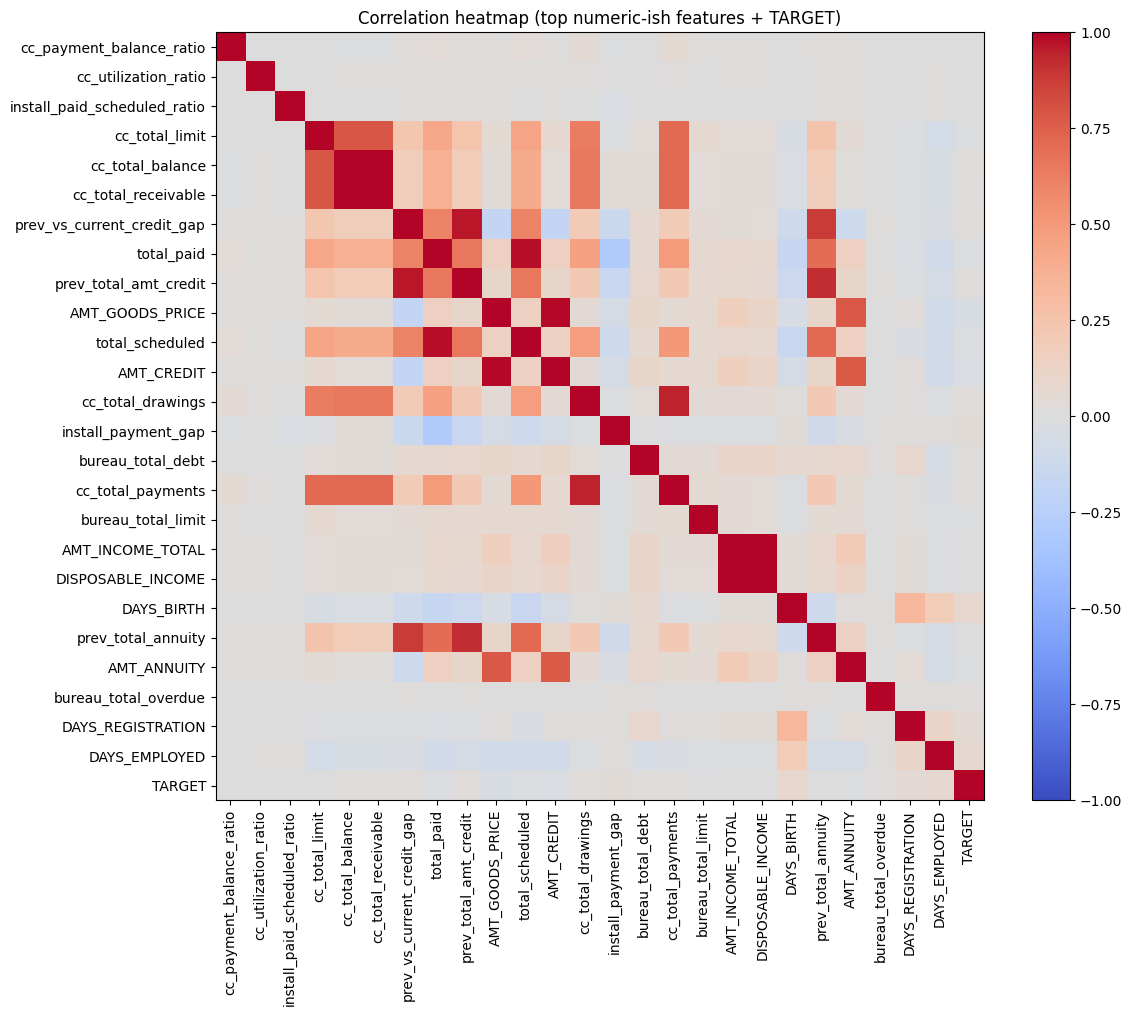

In [ ]:
# 6) Correlation heatmap (top numeric features vs each other)

top_feats = signal_num.head(25).index.tolist()
cols_for_corr = [c for c in top_feats if c in eda_df.columns]

cm = eda_df[cols_for_corr + [TARGET]].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(cm.columns)), cm.columns, rotation=90)
plt.yticks(range(len(cm.columns)), cm.columns)
plt.title("Correlation heatmap (top numeric-ish features + TARGET)")
plt.tight_layout()
plt.show()


In [ ]:
# Step 1: Compute correlation matrix 
top_feats = signal_num.head(15).index.tolist()

corr_matrix = Xtr[top_feats].corr().abs()


# Step 2: Take upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Step 3: Find columns to drop
threshold = 0.85  

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

print(f"Columns to drop ({len(to_drop)}):", to_drop)

# Step 4: Drop from train and test
Xtr = Xtr.drop(columns=to_drop, errors= 'ignore')
Xte = Xte.drop(columns=to_drop, errors= 'ignore')



Columns to drop (4): ['cc_total_receivable', 'prev_total_amt_credit', 'total_scheduled', 'AMT_CREDIT']


In [36]:
print(f"Dropped {len(to_drop)} columns. Xtr shape is now {Xtr.shape}")


Dropped 4 columns. Xtr shape is now (307511, 85)


In [ ]:
# Create the list of important and financial columns
important_cols = signal_num.head(15).index.tolist()
financial_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "bureau_total_debt", "cc_total_limit"]
outlier_candidates = list(set(important_cols + financial_cols))

# Only keep it IF it's numeric AND it was NOT dropped!
final_outlier_cols = [
    c for c in outlier_candidates 
    if pd.api.types.is_numeric_dtype(eda_df[c]) 
    and c not in to_drop   
]

print(f"Checking {len(final_outlier_cols)} columns for outliers...")


Checking 13 columns for outliers...


In [ ]:
# 3) Outlier percentiles for a few key amount-like columns.

outlier_cols = [c for c in final_outlier_cols if c in Xtr.columns]
if outlier_cols:
    perc = [1, 5, 95, 99]
    outlier_rows = []
    for c in outlier_cols:
        vals = Xtr[c].values
        outlier_rows.append([c] + [np.nanpercentile(vals, p) for p in perc])
    outlier_df = pd.DataFrame(outlier_rows, columns=["col"] + [f"p{p}" for p in perc])
    print("\n[Outliers] Percentiles on key amount/risk columns:")
    display(outlier_df)
else:
    print("\n[Outliers] No candidate outlier columns found in Xtr.")



[Outliers] Percentiles on key amount/risk columns:


,col,p1,p5,p95,p99
0,cc_total_drawings,0.000000e+00,0.000,4.994375e+05,1.181171e+06
1,cc_utilization_ratio,0.000000e+00,0.000,7.171387e-01,9.515574e-01
2,total_paid,0.000000e+00,0.000,2.530561e+06,4.288189e+06
3,AMT_GOODS_PRICE,6.750000e+04,135000.000,1.305000e+06,1.800000e+06
4,prev_vs_current_credit_gap,-1.546020e+06,-1021705.515,2.766278e+06,6.084959e+06
5,AMT_INCOME_TOTAL,4.500000e+04,67500.000,3.375000e+05,4.725000e+05
6,cc_total_limit,0.000000e+00,0.000,1.116000e+07,1.692000e+07
7,install_paid_scheduled_ratio,0.000000e+00,0.000,1.211337e+00,1.572215e+00
8,cc_total_balance,0.000000e+00,0.000,4.497767e+06,1.059040e+07
9,install_payment_gap,-7.900215e+05,-159114.735,1.270915e+05,3.646605e+05


In [ ]:
# Handling outliers

# 1) Winsorize/cap using train quantiles
lower_q = 0.01  
upper_q = 0.99  

q_low = Xtr[outlier_cols].quantile(lower_q)
q_high = Xtr[outlier_cols].quantile(upper_q)

Xtr[outlier_cols] = Xtr[outlier_cols].clip(lower=q_low, upper=q_high, axis=1)
Xte[outlier_cols]  = Xte[outlier_cols].clip(lower=q_low, upper=q_high, axis=1)

print("Capped outliers using train p1/p99")



Capped outliers using train p1/p99


In [40]:
# D) Log transforms for skewed positive monetary features
def maybe_log1p(series: pd.Series) -> pd.Series:
    # If non-negative, use log1p. If negatives exist, use signed log1p.
    if series.min(skipna=True) >= 0:
        return np.log1p(series)
    return np.sign(series) * np.log1p(np.abs(series))


log_cols = [c for c in outlier_cols if c in Xtr.columns]

for c in log_cols:
    Xtr[f'log_{c}']= maybe_log1p(Xtr[c])
    Xte[f'log_{c}']= maybe_log1p(Xte[c])

print("Applied log1p (or signed log1p) to skewed amount columns & generated new log1p amount columns")

# Quick check
print("Any remaining NaNs?", int(Xtr.isna().sum().sum()))

Applied log1p (or signed log1p) to skewed amount columns & generated new log1p amount columns
Any remaining NaNs? 0


Plotting 13 log-transformed distributions...


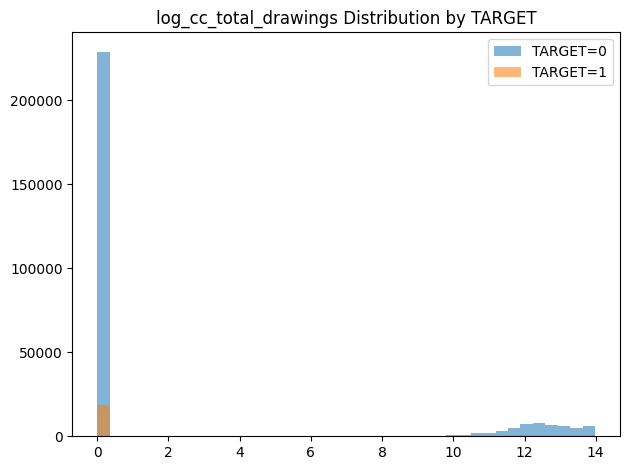

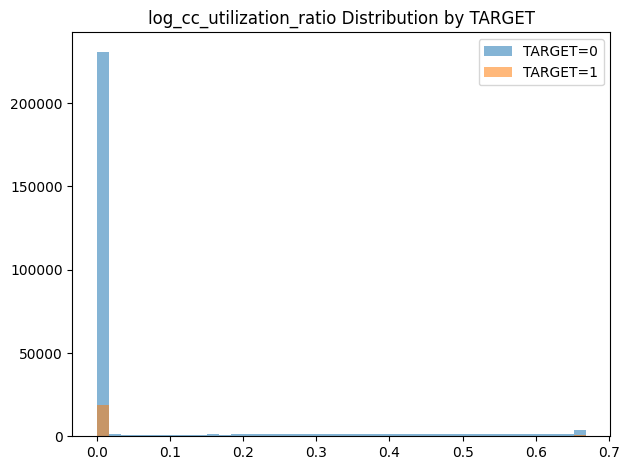

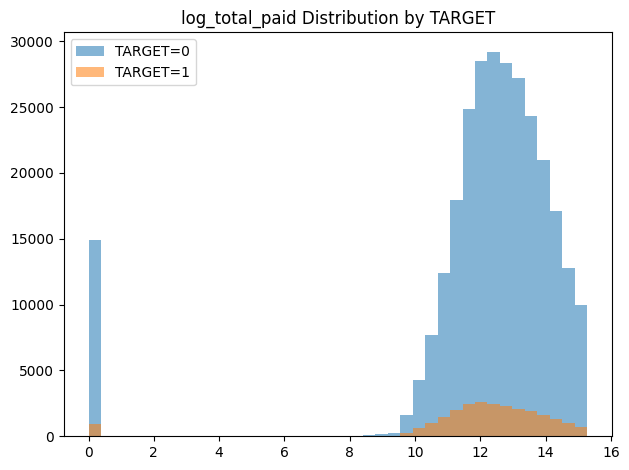

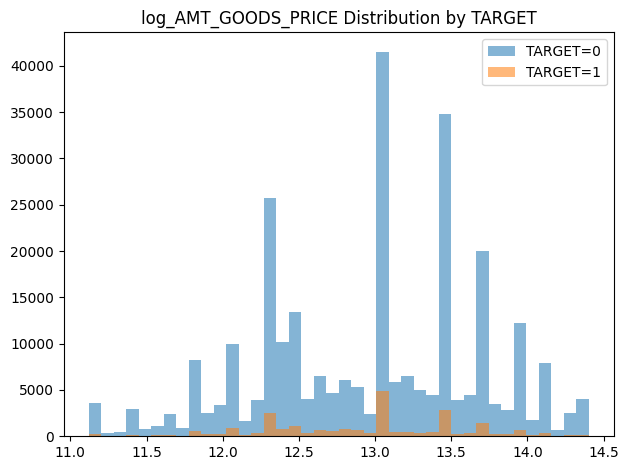

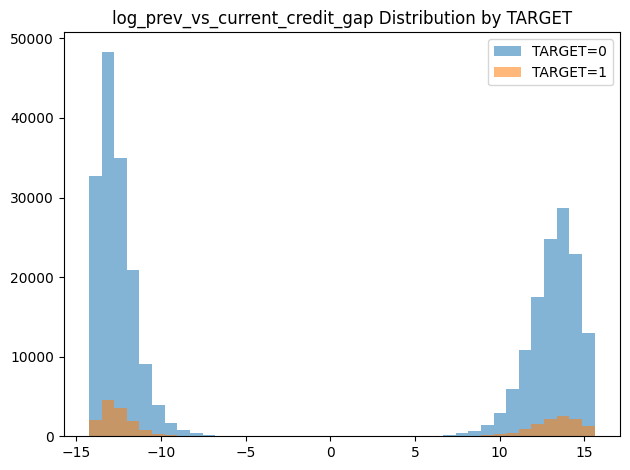

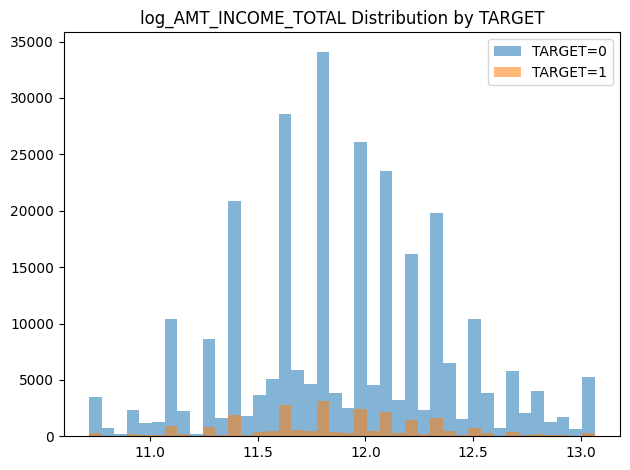

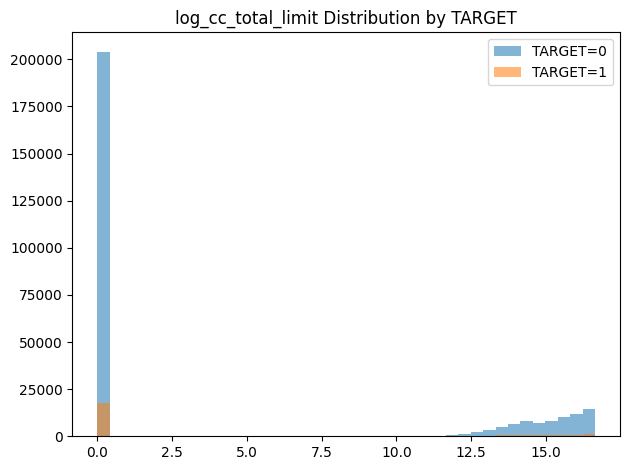

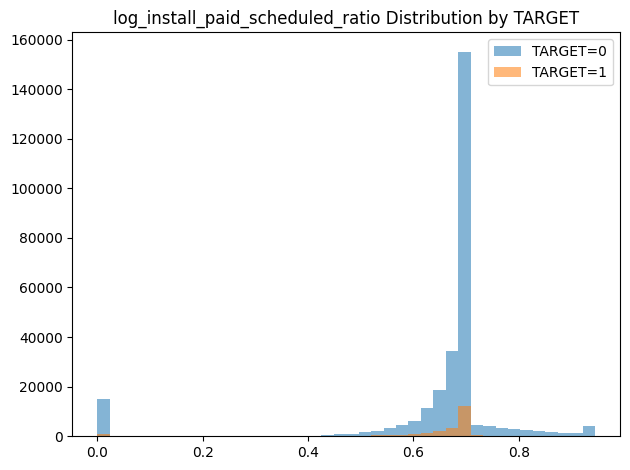

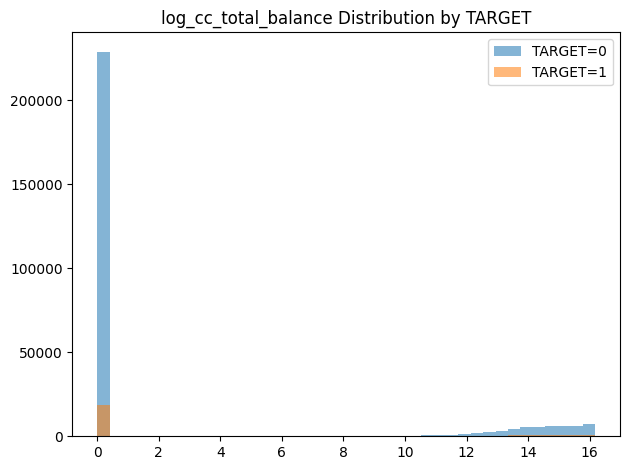

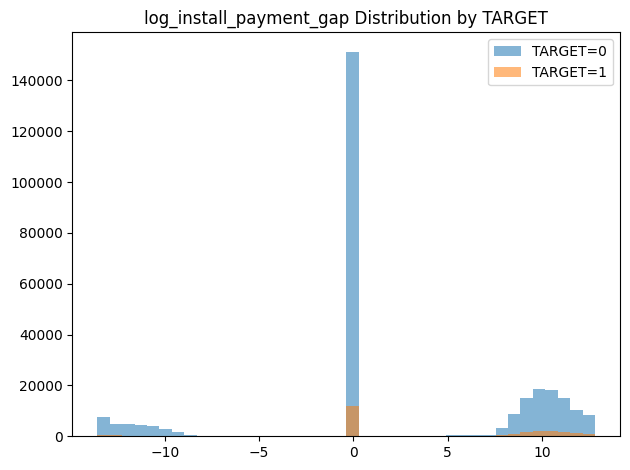

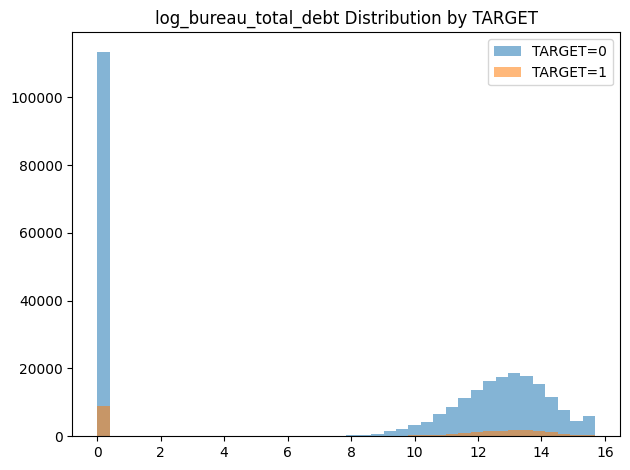

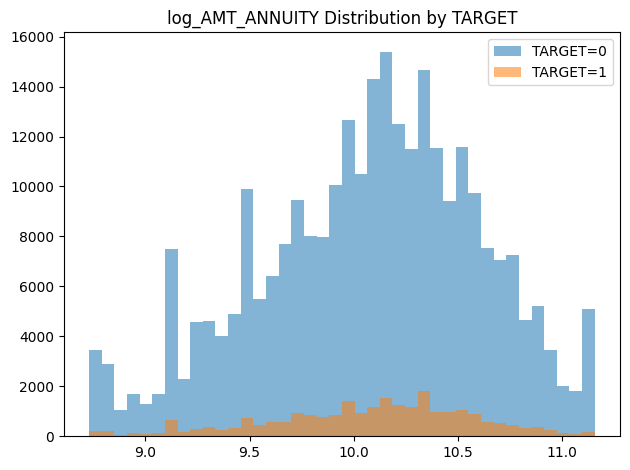

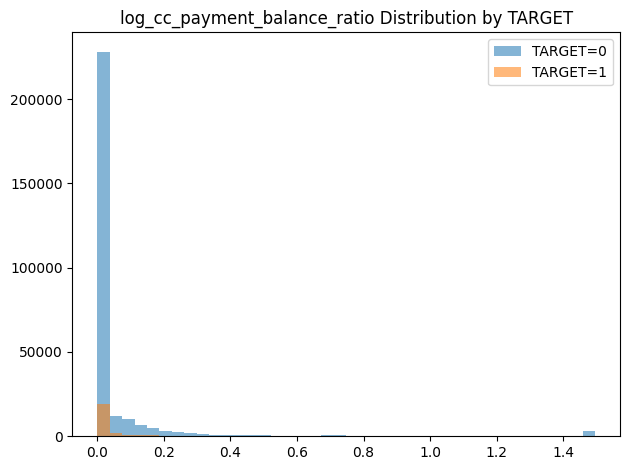

In [ ]:
# 7) Distribution for the new log-transformed columns
# -------------------------
import matplotlib.pyplot as plt


print(f"Plotting {len(log_cols)} log-transformed distributions...")

for c in log_cols:
    log_col_name = f"log_{c}"
    

    if log_col_name in Xtr.columns:
        plt.figure()
        
        
        for t in [0, 1]:
            
            s = Xtr.loc[y == t, log_col_name].dropna()
            
            
            plt.hist(s, bins=40, alpha=0.55, label=f"TARGET={t}")
            
        plt.title(f"{log_col_name} Distribution by TARGET")
        plt.legend()
        plt.tight_layout()
        plt.show()


In [ ]:
# 2a) Drift check on top numeric features (mean/median shift)

active_feats = [c for c in top_feats if c in Xtr.columns]

drift_df = pd.DataFrame({
    "train_mean": Xtr[active_feats].mean(),
    "test_mean": Xte[active_feats].mean(),
    "mean_diff": Xte[active_feats].mean() - Xtr[active_feats].mean(),
    "train_median": Xtr[active_feats].median(),
    "test_median": Xte[active_feats].median(),
    "median_diff": Xte[active_feats].median() - Xtr[active_feats].median(),
    "abs_mean_diff": (Xte[active_feats].mean() - Xtr[active_feats].mean()).abs(),
})

print(f"\n[Drift] Top 10 by abs(mean_diff) among {len(active_feats)} active top features:")
display(drift_df.sort_values("abs_mean_diff", ascending=False).head(10))



[Drift] Top 10 by abs(mean_diff) among 11 active top features:


,train_mean,test_mean,mean_diff,train_median,test_median,median_diff,abs_mean_diff
cc_total_limit,1.583727e+06,1.933544e+06,349816.623363,0.00,0.0000,0.000000e+00,349816.623363
prev_vs_current_credit_gap,2.747338e+05,4.724805e+05,197746.687220,-58486.50,66316.5000,1.248030e+05,197746.687220
total_paid,6.324734e+05,7.330831e+05,100609.728082,289330.02,354110.1975,6.478018e+04,100609.728082
bureau_total_debt,5.089794e+05,5.877301e+05,78750.719833,87583.50,116502.7500,2.891925e+04,78750.719833
AMT_GOODS_PRICE,5.366553e+05,4.628321e+05,-73823.238836,450000.00,396000.0000,-5.400000e+04,73823.238836
cc_total_balance,5.919386e+05,6.410287e+05,49090.112703,0.00,0.0000,0.000000e+00,49090.112703
cc_total_drawings,7.193145e+04,8.028559e+04,8354.138149,0.00,0.0000,0.000000e+00,8354.138149
install_payment_gap,-4.507301e+03,-1.162457e+04,-7117.265136,0.00,0.0000,0.000000e+00,7117.265136
install_paid_scheduled_ratio,9.393742e-01,9.846988e-01,0.045325,1.00,1.0000,4.629963e-12,0.045325
cc_payment_balance_ratio,8.955069e-02,1.257093e-01,0.036159,0.00,0.0000,0.000000e+00,0.036159


In [43]:
# 4) Categorical cardinality 
card = pd.Series({c: Xtr[c].nunique(dropna=False) for c in cat_cols}).sort_values(ascending=False)
print("\n[Cardinality] Categorical columns (top 15 by #unique):")
display(card.head(15))



[Cardinality] Categorical columns (top 15 by #unique):


OCCUPATION_TYPE        12
NAME_FAMILY_STATUS      6
NAME_INCOME_TYPE        5
NAME_EDUCATION_TYPE     5
NAME_HOUSING_TYPE       5
CODE_GENDER             3
NAME_CONTRACT_TYPE      2
dtype: int64

In [44]:
#Train-test schema check :

print(set(Xtr.columns) == set(Xte.columns))

True


In [45]:
# Removing Constant/near-constant features :

const_cols = [c for c in Xtr.columns if Xtr[c].nunique(dropna=False) <= 1]
print("constant cols:", const_cols)

constant cols: []


In [46]:
%pip install lightgbm


Note: you may need to restart the kernel to use updated packages.


### Model training

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
try:
    from lightgbm import LGBMClassifier
except ImportError:
    raise ImportError("Pip install lightgbm")
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    f1_score,
)

try:
    from xgboost import XGBClassifier
except ImportError:
    raise ImportError("pip install xgboost")

import shap

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

y_arr = np.asarray(y.values if hasattr(y, "values") else y)

num_cols = [c for c in Xtr.columns if pd.api.types.is_numeric_dtype(Xtr[c])]
cat_cols = [c for c in Xtr.columns if c not in num_cols]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

scaler = StandardScaler()

preprocess = ColumnTransformer(
    [("num", scaler, num_cols), ("cat", ohe, cat_cols)]
)

X_train, X_val, y_train, y_val = train_test_split(
    Xtr, y_arr, test_size=0.35, stratify=y_arr, random_state=RANDOM_STATE
)



In [48]:
print("Train shape:", X_train.shape, "| Val shape:", X_val.shape)

Train shape: (199882, 98) | Val shape: (107629, 98)


In [49]:
# imbalance ratio for XGBoost
import time

scale_pos_weight = float((y_train == 0).sum() / max(1, (y_train == 1).sum()))
print("scale_pos_weight:", round(scale_pos_weight, 3))

def evaluate_model(name, pipe):
    t0 = time.time()
    pipe.fit(X_train, y_train)
    fit_sec = time.time() - t0

    p = pipe.predict_proba(X_val)[:, 1]
    pred = (p >= 0.5).astype(int)

    row = {
        "model": name,
        "fit_time_sec": round(fit_sec, 2),
        "accuracy": accuracy_score(y_val, pred),
        "roc_auc": roc_auc_score(y_val, p),
        "pr_auc": average_precision_score(y_val, p),
        "f1@0.5": f1_score(y_val, pred, zero_division=0),
    }
    return row, pipe

results = []
fitted_models = {}



scale_pos_weight: 11.387


In [ ]:
# ----------------------------
# 2) Logistic Regression
# ----------------------------
pipe_lr = Pipeline(
    steps=[
        ("prep", preprocess),
        ("model", LogisticRegression(
            max_iter=150,              
            class_weight="balanced",
            solver="lbfgs",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]
)

row, mdl = evaluate_model("logistic_regression", pipe_lr)
results.append(row)
fitted_models["logistic_regression"] = mdl
print("Done: logistic_regression", row)



c:\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Done: logistic_regression {'model': 'logistic_regression', 'fit_time_sec': 7.4, 'accuracy': 0.6966059333451021, 'roc_auc': 0.7680843759363117, 'pr_auc': 0.24863740493896036, 'f1@0.5': 0.2729661130159861}


In [ ]:
# ----------------------------
# 3) Random Forest
# ----------------------------
pipe_rf = Pipeline(
    steps=[
        ("prep", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=120,           
            max_depth=10,               
            min_samples_leaf=80,        
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]
)

row, mdl = evaluate_model("random_forest", pipe_rf)
results.append(row)
fitted_models["random_forest"] = mdl
print("Done: random_forest", row)



Done: random_forest {'model': 'random_forest', 'fit_time_sec': 16.11, 'accuracy': 0.7224911501546981, 'roc_auc': 0.7593027488547437, 'pr_auc': 0.24550586330125918, 'f1@0.5': 0.2746612268687163}


In [ ]:
# ----------------------------
# 4) XGBoost (separate run)
# ----------------------------
pipe_xgb = Pipeline(
    steps=[
        ("prep", preprocess),
        ("model", XGBClassifier(
            n_estimators=220,           
            learning_rate=0.08,         
            max_depth=5,              
            min_child_weight=100,       
            subsample=0.8,
            colsample_bytree=0.7,
            objective="binary:logistic",
            eval_metric="auc",
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist"
        ))
    ]
)

row, mdl = evaluate_model("xgboost", pipe_xgb)
results.append(row)
fitted_models["xgboost"] = mdl
print("Done: xgboost", row)


Done: xgboost {'model': 'xgboost', 'fit_time_sec': 6.03, 'accuracy': 0.7263562794414145, 'roc_auc': 0.7806698309015372, 'pr_auc': 0.27384238935316985, 'f1@0.5': 0.28945717732207477}


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

pipe_ext = Pipeline(
    steps=[
        ("prep", preprocess),
        (
            "model",
            ExtraTreesClassifier(
                n_estimators=300,        
                max_depth=12,
                min_samples_leaf=80,
                class_weight="balanced",  
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

row, mdl = evaluate_model("extratrees", pipe_ext)
results.append(row)
fitted_models["extratrees"] = mdl
print("Done: extratrees", row)


Done: extratrees {'model': 'extratrees', 'fit_time_sec': 27.18, 'accuracy': 0.6926386011205159, 'roc_auc': 0.7542360728172537, 'pr_auc': 0.23482428256994922, 'f1@0.5': 0.2632458074430414}


In [ ]:
from lightgbm import LGBMClassifier

# ----------------------------
# 3) LightGBM Pipeline
# ----------------------------
pipe_lgbm = Pipeline(
    steps=[
        ("prep", preprocess), 
        ("model", LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

# Run evaluation and save results
row_lgbm, mdl_lgbm = evaluate_model("lightgbm", pipe_lgbm)
results.append(row_lgbm)
fitted_models["lightgbm"] = mdl_lgbm

print("Done: lightgbm")
print("\nLightGBM Metrics:")
print(f"ROC-AUC: {row_lgbm['roc_auc']:.4f}")
print(f"F1@0.5:  {row_lgbm['f1@0.5']:.4f}")


[LightGBM] [Info] Number of positive: 16136, number of negative: 183746
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.115435 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16177
[LightGBM] [Info] Number of data points in the train set: 199882, number of used features: 125
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\anaconda3\envs\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Done: lightgbm

LightGBM Metrics:
ROC-AUC: 0.7795
F1@0.5:  0.2896


In [55]:
# ----------------------------
# 5) Compare all
# ----------------------------
results_df = pd.DataFrame(results).set_index("model").sort_values("roc_auc", ascending=False)
display(results_df.round(4))

best_model_name = results_df.index[0]
best_model = fitted_models[best_model_name]
print("Best model by ROC-AUC:", best_model_name)
print("Accuracy of best model:", round(results_df.loc[best_model_name, "accuracy"], 4))

,fit_time_sec,accuracy,roc_auc,pr_auc,f1@0.5
model,,,,,
xgboost,6.03,0.7264,0.7807,0.2738,0.2895
lightgbm,7.43,0.7293,0.7795,0.2717,0.2896
logistic_regression,7.40,0.6966,0.7681,0.2486,0.2730
random_forest,16.11,0.7225,0.7593,0.2455,0.2747
extratrees,27.18,0.6926,0.7542,0.2348,0.2632


Best model by ROC-AUC: xgboost
Accuracy of best model: 0.7264


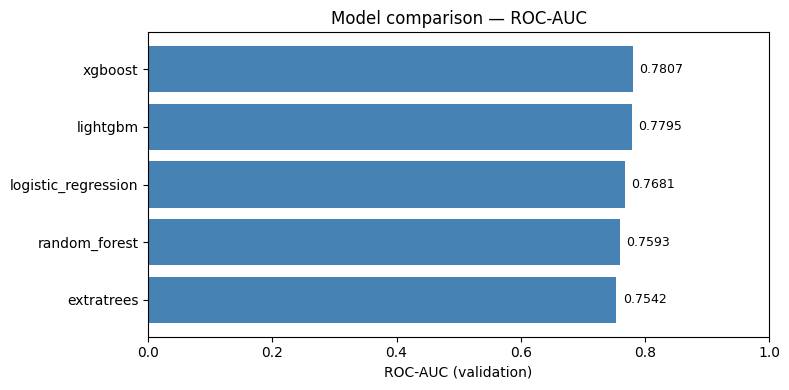

In [ ]:
# ROC-AUC model comparison
import matplotlib.pyplot as plt
import pandas as pd



plot_df = results_df.copy()
if "roc_auc" not in plot_df.columns:
    raise ValueError("results_df must contain a 'roc_auc' column")

plot_df = plot_df.sort_values("roc_auc", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(plot_df.index.astype(str), plot_df["roc_auc"], color="steelblue")
ax.set_xlabel("ROC-AUC (validation)")
ax.set_title("Model comparison — ROC-AUC")
ax.set_xlim(0, 1)
for i, v in enumerate(plot_df["roc_auc"]):
    ax.text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Research gap 1: saved table for report / reproducibilitCredit default datasets are highly imbalanced (defaults are much fewer than non-defaults). If imbalance is ignored, models can achieve high accuracy by mostly predicting the majority class, while still failing to detect defaults. Many papers also rely mainly on accuracy, which does not fully reflect performance on the minority class.

'''Credit default datasets are highly imbalanced (defaults are much fewer than non-defaults). 
If imbalance is ignored, models can achieve high accuracy by mostly predicting the majority class, 
while still failing to detect defaults. Many papers also rely mainly on accuracy, 
which does not fully reflect performance on the minority class.
In this project, we address this gap by using a stratified train–validation split to preserve the default rate,
applying imbalance-aware training (class_weight for Logistic Regression and Random Forest, and scale_pos_weight for XGBoost),
and evaluating models using ROC-AUC, PR-AUC, F1-score, and accuracy together. 
The comparative results are summarized in Table X , where ROC-AUC and F1 are emphasized for minority-class performance,
while accuracy is reported for completeness.'''






'Credit default datasets are highly imbalanced (defaults are much fewer than non-defaults). \nIf imbalance is ignored, models can achieve high accuracy by mostly predicting the majority class, \nwhile still failing to detect defaults. Many papers also rely mainly on accuracy, \nwhich does not fully reflect performance on the minority class.\nIn this project, we address this gap by using a stratified train–validation split to preserve the default rate,\napplying imbalance-aware training (class_weight for Logistic Regression and Random Forest, and scale_pos_weight for XGBoost),\nand evaluating models using ROC-AUC, PR-AUC, F1-score, and accuracy together. \nThe comparative results are summarized in Table X , where ROC-AUC and F1 are emphasized for minority-class performance,\nwhile accuracy is reported for completeness.'

C:\Users\Anamika Mishra\AppData\Local\Temp\ipykernel_50872\3583172250.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_dense, feature_names=fnames, max_display=15, show=False)


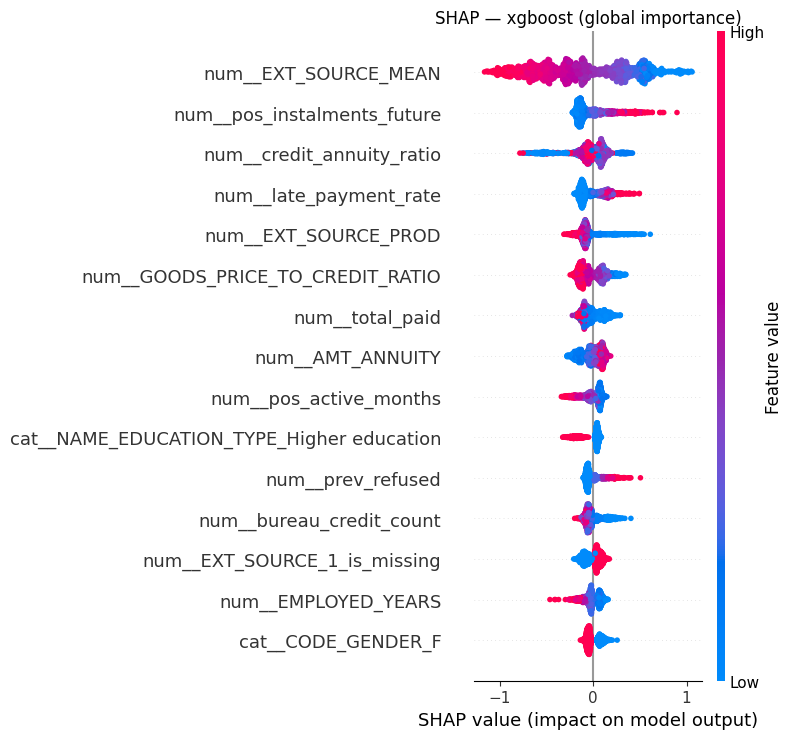

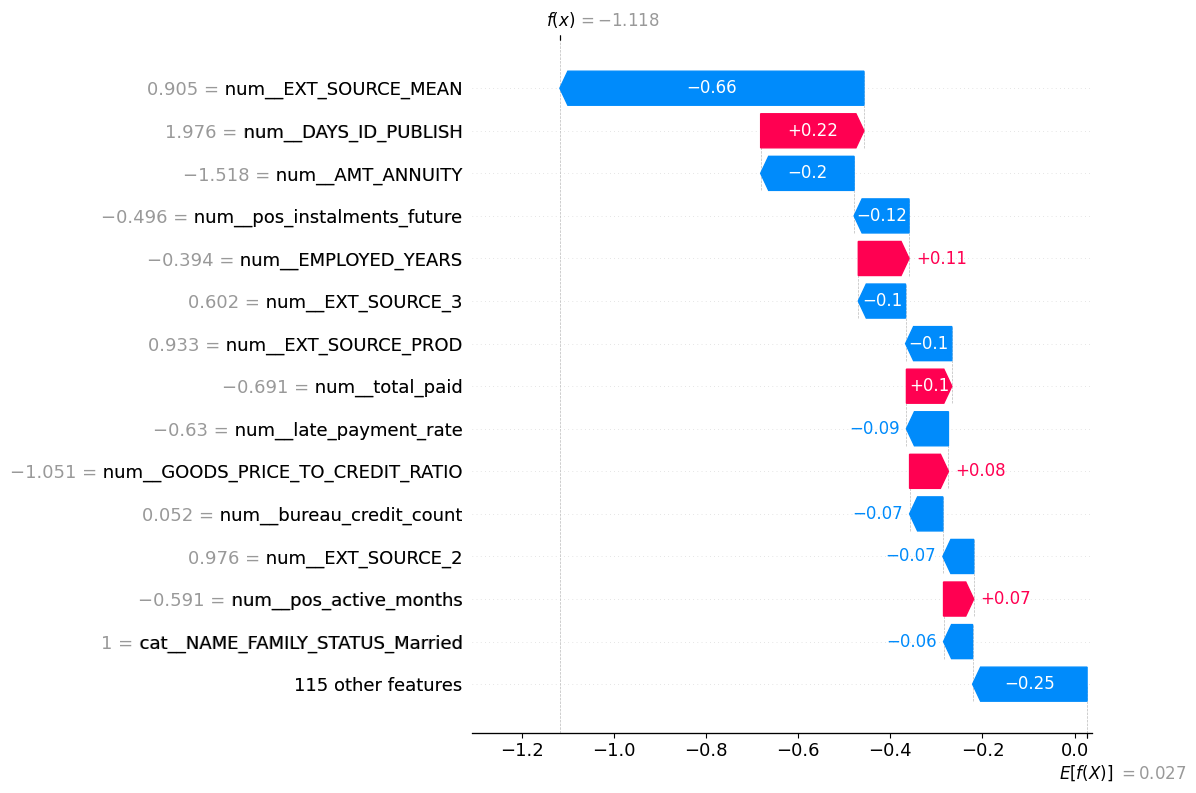

In [ ]:
#  SHAP transparency on best TREE model 
best_pipe = fitted_models[best_model_name]
best_name = best_model_name 
if best_model_name not in ("random_forest", "xgboost"):
    print("SHAP tree plot: switching to xgboost for TreeExplainer.")
    best_pipe = fitted_models["xgboost"]
    best_name = "xgboost"

prep = best_pipe.named_steps["prep"]
tree = best_pipe.named_steps["model"]
fnames = list(prep.get_feature_names_out())

n = min(1500, len(X_val))
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_val), n, replace=False)
Xv = X_val.iloc[idx]
Xt = prep.transform(Xv)
X_dense = Xt.toarray() if hasattr(Xt, "toarray") else np.asarray(Xt)

explainer = shap.TreeExplainer(tree)
shap_values = explainer.shap_values(X_dense)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

plt.figure()
shap.summary_plot(shap_values, X_dense, feature_names=fnames, max_display=15, show=False)
plt.title(f"SHAP — {best_name} (global importance)")
plt.tight_layout()
plt.show()

# One applicant (local explanation)
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value[1] if hasattr(explainer.expected_value, "__len__") else explainer.expected_value,
        data=X_dense[0],
        feature_names=fnames,
    ),
    max_display=15,
)
plt.show()

In [61]:
%pip install jinja2


   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]

Note: you may need to restart the kernel to use updated packages.


--- FINAL BUSINESS RISK REPORT (Test Dataset) ---


,RISK_TIER,Total_Applicants,%_of_Total,Average_Risk,Avg_Income,Avg_GOODS_PRICE_Requested
0,1_Low_Risk (Approve),12047,24.7%,12.8%,"$187,785","$505,114"
1,2_Medium_Risk (Review),15779,32.4%,29.5%,"$174,563","$480,834"
2,3_High_Risk (Reject),20918,42.9%,59.9%,"$170,419","$424,901"


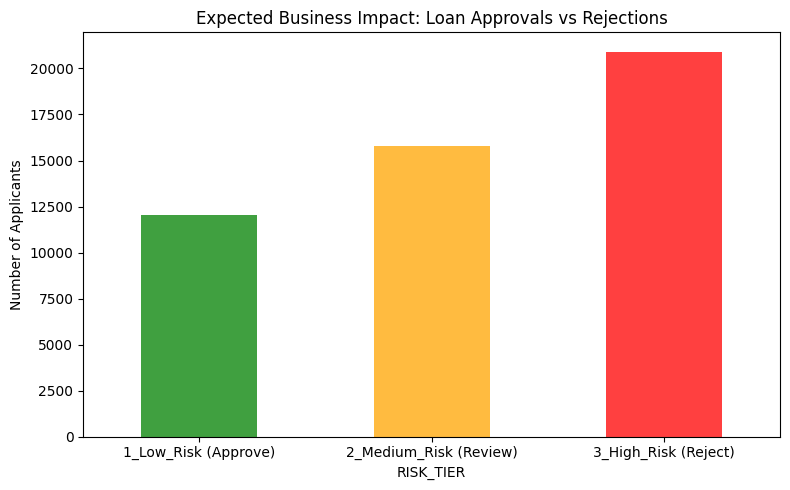

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("--- FINAL BUSINESS RISK REPORT (Test Dataset) ---")

# 1. Grab your winning XGBoost model
best_model = fitted_models["xgboost"]

# 2. Predict the exact risk probability for all new applicants
test_risk_scores = best_model.predict_proba(Xte)[:, 1]

# 3. Create a Business Report DataFrame
report_df = Xte.copy()
report_df["RISK_SCORE"] = test_risk_scores

# 4. Define Banking Business Logic (Thresholds)

def assign_risk_tier(score):
    if score >= 0.40:
        return "3_High_Risk (Reject)"
    elif score >= 0.20:
        return "2_Medium_Risk (Review)"
    else:
        return "1_Low_Risk (Approve)"

report_df["RISK_TIER"] = report_df["RISK_SCORE"].apply(assign_risk_tier)

# 5. Build the Summary Table
business_summary = report_df.groupby("RISK_TIER").agg(
    Total_Applicants = ("RISK_SCORE", "count"),
    Average_Risk = ("RISK_SCORE", lambda x: f"{x.mean()*100:.1f}%"),
    Avg_Income = ("AMT_INCOME_TOTAL", "mean"),
    Avg_GOODS_PRICE_Requested = ("AMT_GOODS_PRICE", "mean")
).reset_index()

# Calculate what percentage of applicants fall into each bucket
business_summary["%_of_Total"] = (business_summary["Total_Applicants"] / len(report_df) * 100).round(1).astype(str) + "%"

# Reorder columns to look pretty
business_summary = business_summary[["RISK_TIER", "Total_Applicants", "%_of_Total", "Average_Risk", "Avg_Income", "Avg_GOODS_PRICE_Requested"]]

display(business_summary.style.format({
    "Avg_Income": "${:,.0f}",
    "Avg_GOODS_PRICE_Requested": "${:,.0f}"
}))

# 6. Plot the final business decision breakdown
plt.figure(figsize=(8, 5))
tier_counts = report_df["RISK_TIER"].value_counts().sort_index()
tier_counts.plot(kind="bar", color=["green", "orange", "red"], alpha=0.75)
plt.title("Expected Business Impact: Loan Approvals vs Rejections")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
import joblib
import json

print("--- EXPORTING FOR DEPLOYMENT ---")

# 1. Save the absolute best Model Pipeline (XGBoost)
winner_model = fitted_models["xgboost"]

joblib.dump(winner_model, "model_pipeline.pkl")
print("[v] Saved 'model_pipeline.pkl' successfully.")

# 2. Extract a "Baseline Applicant" profile.
# pulled a single row from X_train (the fully clean, raw data BEFORE feature engineering)
baseline_series = X_train.iloc[0].copy()

# Converted to a dictionary and save as JSON
baseline_dict = baseline_series.to_dict()
with open("baseline_applicant.json", "w") as f:
    json.dump(baseline_dict, f, indent=4)

print("[v] Saved 'baseline_applicant.json' successfully.")


--- EXPORTING FOR DEPLOYMENT ---
[v] Saved 'model_pipeline.pkl' successfully.
[v] Saved 'baseline_applicant.json' successfully.
